# Strategy analysis

## Imports and data loading

In [1]:
%load_ext autoreload
%autoreload 2

import collections.abc as collections
import copy
import datetime
import glob
import os
import pickle
import sys

import numpy as np
import pandas as pd
import scipy
import torch
import statsmodels.api as sm
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

sys.path.append("..")
import utils

In [2]:
DATA_DIR = ".."  # the root directory of the project

os.chdir(DATA_DIR)

In [3]:
def flatten(d, parent_key='', sep='_'):
    """
    Flattens a nested dictionary with string keys to a flat dictionary using 
    `sep` to concatenate keys at different levels, and using `parent_key` as
    the top-level key.
    """
    items = []
    for k, v in d.items():
        new_key = parent_key + sep + k if parent_key else k
        if isinstance(v, collections.MutableMapping):
            items.extend(flatten(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


def load_results(results_directory_path:str, drop_static_columns=False):
    """
    Loads pickle file results in `results_directory_path` and organizes them into a pandas.DataFrame.
    Generally this works best setting `results_directory_path` to a subdir of the results directory,
    such as CNNTransformer, instead of the top-level results directory.
    """
    def _add_config(d, config, results_key):
        if 'factor_model' not in config and 'num_factors' not in config:
            fminfo = results_key.split("__", 1)[0]
            config['factor_model'] = ''.join([c for c in fminfo if not c.isdigit()])
            config['num_factors'] = int(''.join([c for c in fminfo if c.isdigit()]))
        if 'factor_models' in config:
            del config['factor_models']
        config = flatten(config, sep='.')
        for config_var in config.keys():
            dd[config_var] = config[config_var]
    
    results_dicts = []
    filepaths = glob.glob(os.path.join(results_directory_path, '**', '*.pickle'), recursive=False) \
              + glob.glob(os.path.join(results_directory_path, '*.pickle'), recursive=False)
    for fp in filepaths:
        end_ts = os.path.getmtime(fp)
        end_dt = datetime.datetime.fromtimestamp(end_ts)
        with open(fp, 'rb') as f:
            d = pickle.load(f)
        for results_key in d.keys():
            dd = d[results_key].copy()
            c = dd['config']
            del dd['config']
            dd['filepath'] = fp
            dd['end_time'] = end_dt
            dd['start_time'] = dd.pop('timestamp')
            if 'turnover' in dd:
                dd['turnovers'] = dd.pop('turnover')
            dd['turnover'] = np.mean(dd['turnovers'])
            if 'short_proportion' in dd:
                dd['short_proportions'] = dd.pop('short_proportion')
            dd['short_proportion'] = np.mean(dd['short_proportions'])
            _add_config(dd, c, results_key)
            results_dicts.append(dd)
    df = pd.DataFrame.from_dict(results_dicts)
    if drop_static_columns:
        # drop columns which are all the same value
        cols_to_drop = []
        for c in df.columns:
            try:
                if df[c].nunique(dropna=False) == 1:
                    cols_to_drop.append(c)
            except:
                pass  # for columns which contain unhashable values, nunique may fail
        df.drop(cols_to_drop, axis=1, inplace=True)
    return df

In [4]:
def ann_sharpe(x):
    return np.sqrt(252) * np.mean(x, axis=0) / np.std(x, axis=0)
def ann_ret(x):
    return 252 * np.mean(x, axis=0)
def ann_std(x):
    return np.sqrt(252) * np.std(x, axis=0)

def b_sharpe(x, b):
    return np.sqrt(252/b) * np.mean(x, axis=0) / np.std(x, axis=0)
def b_ret(x, b):
    return 252/b * np.mean(x, axis=0)
def b_std(x, b):
    return np.sqrt(252/b) * np.std(x, axis=0)

def b_stat(x, bs, stat_func=b_sharpe):
    Bs = np.array(bs)
    X = x * Bs
    stats = np.zeros(len(bs))
    for (i,B) in enumerate(Bs):
        stats_b = np.zeros(B)
        for t in range(B):
            stats_b[t] = stat_func(X[t::B,i], B)
        stats[i] = np.mean(stats_b)
    return stats

In [5]:
z = np.load("saved-results/cnn_transformer/DatasetDictionaryDef_Sharpe-1.pickle", allow_pickle=True)
list(z.keys())
results_tag = "IPCA5_0transCost_0holdCost_residualWeights_Sharpe_normalized_CNNTransformer_30lookback_1000lengthTraining_[1, 8]filters_4attention_0.25dropout_16hiddenunits"
w = np.load(f"saved-results/cnn_transformer/WeightsComplete_{results_tag}.npy")
r = np.load("saved-results/cnn_transformer/DatasetDictionaryDef_Sharpe-1.pickle", allow_pickle=True)[results_tag.replace("Weights_Sharpe_normalized", "Weights")][0]

In [6]:
zf = np.load("saved-results/cnn_transformer_frictions/DatasetDictionaryDef_Sharpe-1.pickle", allow_pickle=True)
for k in zf.keys():
    print(k)
results_tag_f = [k for k in zf.keys() if 'IPCA5' in k][0]
frictions_weights_path = f"saved-results/cnn_transformer_frictions/WeightsComplete_{results_tag_f}.npy"
print(frictions_weights_path)
wf = np.load(frictions_weights_path)
rf = zf[results_tag_f][0]

IPCA1_0.0005transCost_0.0001holdCost_residualWeights_Sharpe_normalized_CNNTransformerPrevious_30lookback_1000lengthTraining_[1, 8]filters_4attention_0.25dropout_16hiddenunits
IPCA3_0.0005transCost_0.0001holdCost_residualWeights_Sharpe_normalized_CNNTransformerPrevious_30lookback_1000lengthTraining_[1, 8]filters_4attention_0.25dropout_16hiddenunits
IPCA5_0.0005transCost_0.0001holdCost_residualWeights_Sharpe_normalized_CNNTransformerPrevious_30lookback_1000lengthTraining_[1, 8]filters_4attention_0.25dropout_16hiddenunits
IPCA10_0.0005transCost_0.0001holdCost_residualWeights_Sharpe_normalized_CNNTransformerPrevious_30lookback_1000lengthTraining_[1, 8]filters_4attention_0.25dropout_16hiddenunits
IPCA15_0.0005transCost_0.0001holdCost_residualWeights_Sharpe_normalized_CNNTransformerPrevious_30lookback_1000lengthTraining_[1, 8]filters_4attention_0.25dropout_16hiddenunits
FamaFrench0_0.0005transCost_0.0001holdCost_residualWeights_Sharpe_normalized_CNNTransformerPrevious_30lookback_1000lengthTr

In [8]:
super_mask = np.load("residuals-replication/ipca/super_mask_0.01.npy")

In [9]:
try:
    resids = np.load("residuals-replication/ipca/IPCA_DailyOOSresiduals_5_factors_420_initialMonths_240_window_12_reestimationFreq_0.01_cap.npy", allow_pickle=True)
except FileNotFoundError:
    resids = np.load("residuals-replication/ipca/IPCA_DailyOOSresiduals_5_factors_420_initialMonths_240_window_0.01_cap.npy", allow_pickle=True)

In [10]:
try:
    cm = np.load("residuals-replication/ipca/IPCA_DailyMatrixOOSresiduals_5_factors_420_initialMonths_240_window_12_reestimationFreq_0.01_cap.npy", allow_pickle=True)
except FileNotFoundError:
    cm = np.load("residuals-replication/ipca/IPCA_DailyMatrixOOSresiduals_5_factors_420_initialMonths_240_window_0.01_cap.npy", allow_pickle=True)

In [11]:
fma2c = np.load("residuals-replication/ipca/assets-to-consider_1998_initialOOSYear_0.01_cap.npy", allow_pickle=True)

In [12]:
dailyData = np.load('data/DailyReturns-RFadjusted.npz', allow_pickle=True)
oosdates = pd.to_datetime(dailyData['date'], format='%Y%m%d')[-r.shape[0]:]

oosrets = dailyData['data'][-r.shape[0]:,:]
oosrets[np.isnan(oosrets)] = 0

oosrets.shape

(3781, 9483)

In [13]:
#FONT SIZE IN PLOTS
SMALL_SIZE = 11
MEDIUM_SIZE = 11
BIGGER_SIZE = 11

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

if not os.path.exists("plots/strategy-analysis"):
    os.makedirs("plots/strategy-analysis")

## Analysis

### Weight distribution

In [14]:
def plot_weight_distribution(w: np.ndarray, oosdates: np.ndarray, bins=20, tag:str=None):
    wt = w[w != 0]
    weights = np.ones_like(wt)/float(len(wt))
    plt.hist(wt, bins=bins, weights=weights)
    plt.title(f"Histogram of weights{f' ({tag})' if tag else ''}")
    plt.xlim([-.01, .01])
    plt.xticks([-0.01, -0.005, 0, 0.005, 0.01])
    # plt.savefig(f"plots/strategy-analysis/weights-histogram{'_'+tag if tag else ''}.png")
    plt.figure()
    # fit normal distribution to the data
    mu, std = scipy.stats.norm.fit(wt)
    # plot histogram
    plt.hist(wt, bins=20, density=True)
    # plot the pdf
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = scipy.stats.norm.pdf(x, mu, std)
    plt.plot(x, p, 'k', linewidth=1)
    plt.xlim([-.015, .015])
    title = "Weights histogram, Fit: $\mu=$%0.6f,  $\sigma=$%0.6f" % (mu, std)
    plt.title(title + (f" ({tag})" if tag else ''))
    # plt.savefig(f"plots/strategy-analysis/weights-histogram-fit{'_'+tag if tag else ''}.png")
    plt.show()

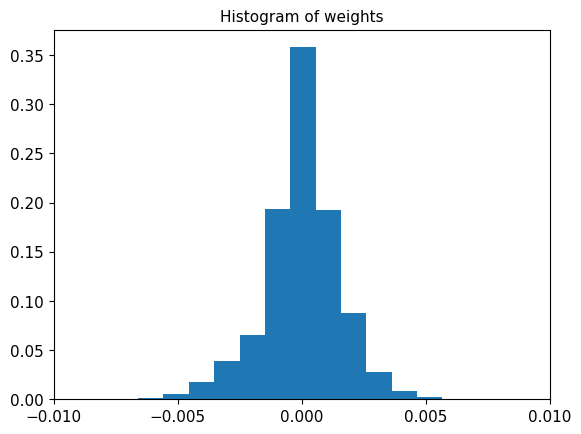

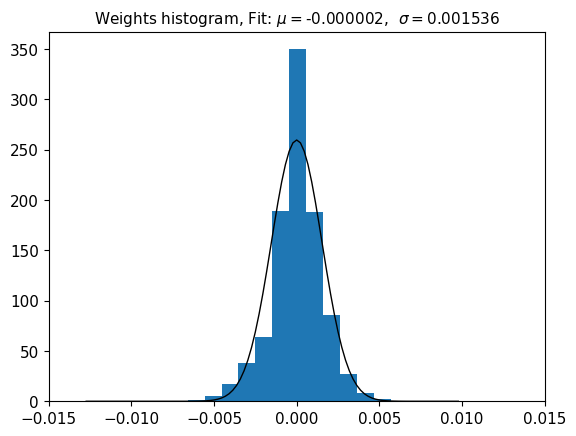

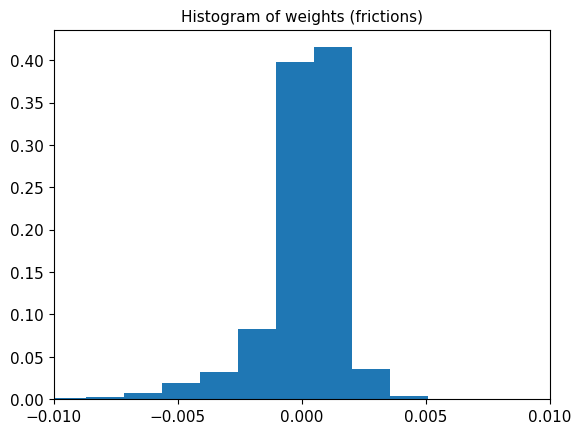

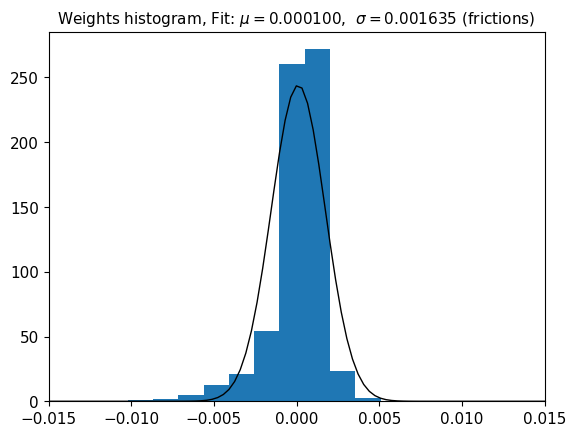

In [15]:
plot_weight_distribution(w, oosdates, tag=None)
plot_weight_distribution(wf, oosdates, tag="frictions")

## Persistence of arbitrage

### B-day trading, overlapping

In [16]:
def compute_blended_returns(
    w: np.ndarray,
    oosdates: np.ndarray,
    oosrets: np.ndarray,
    days: list,
    tag: str = None,
):
    save_filepath = f"saved-results/arb_rets{'_'+tag if tag else ''}.npy"
    if os.path.exists(save_filepath):
        return np.load(save_filepath)
    T = len(oosdates)
    max_days = max(days)
    arb_rets = np.zeros((T - len(days), len(days)))
    for (t,d) in enumerate(oosdates[:-max_days]):
        for tau in days:
            # compute blended return over last tau portfolios
            if t < max_days:
                arb_rets[t,days.index(tau)] = 0
            else:
                tt_portfolio_weights = np.zeros_like(w[0:1,:])
                for tt in range(0,tau):
                    tt_portfolio_weights += 1/tau * w[t+tt-tau+1:t+tt-tau+1+1,:]
                arb_rets[t,days.index(tau)] = tt_portfolio_weights @ oosrets[t:t+1,:].T
        if t % 300 == 0:
            print(datetime.datetime.now(), f"at day {t}/{len(oosdates)}")
    print(datetime.datetime.now(), "done")
    np.save(save_filepath, arb_rets)
    return arb_rets

def plot_arb_persistence(
    arb_rets: np.ndarray,
    opt_arb_rets: np.ndarray,
    oosdates: np.ndarray,
    days=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 15, 22, 30],
    tag: str = None,
):
    """
    Takes in a (T,B)-shaped np.ndarray of `arb_rets` and `opt_arb_rets`, where
    each index in B corresponds to a number of blending days in `days`, e.g.
    if `arb_rets` and `opt_arb_rets` are both (3781,3)-shaped and `days` is 
    [5,10,15], then the returns of the first column of `arb_rets` and `opt_arb_rets`
    is the 5-day blended returns, the second column is the 10-day blended returns, etc.
    """
    max_days = max(days)
    
    for (agg_name, agg_var, agg_func) in [('Annualized Sharpe ratio', 'sharpe', ann_sharpe), 
                                          ('Annualized mean return', 'mean', ann_ret), 
                                          ('Annualized volatility', 'std', ann_std)]:
        plt.figure()
        plt.plot(days, agg_func(arb_rets), marker="x", linewidth=1, label="1-day trading objective", markersize=10)
        plt.plot(days, agg_func(opt_arb_rets), marker="x", linewidth=1, label="B-day trading objective", markersize=10)
        plt.title(f"{agg_name} of blending portfolio for B trading days")
        plt.xlabel("B", fontsize=12)
        plt.ylabel(agg_name, fontsize=12)
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        if 'Sharpe' in agg_name:
            plt.legend(loc="upper right", fontsize=12)
        # plt.savefig(f"plots/strategy-analysis/persistence_{agg_var}.png", bbox_inches='tight')
        plt.show()
            
def plot_arb_persistence_stats(arb_stats: np.ndarray,
                               opt_arb_stats: np.ndarray,
                               oosdates: np.ndarray,
                               days = [1,2,3,4,5,6,7,8,9,10,11,15,22,30],
                               tag:str = None,
                              ):
    """
    Takes in a (S,B)-shaped np.ndarray of `arb_stats` and `opt_arb_stats`, where
    each index in B corresponds to a number of blending days in `days`, e.g.
    same as in `plot_arb_persistence()`
    Assumes stats are, in order:
    sharpe, ret, std, turnover, short_proportion, leverage
    Only plots and saves stats, not sub-period stats
    """
    max_days = max(days)
    
    for (i, agg_info) in enumerate([('Annualized Sharpe ratio', 'sharpe'), 
                                    ('Annualized mean return', 'mean'), 
                                    ('Annualized volatility', 'std'),
                                    ]):
        (agg_name, agg_var) = agg_info
        plt.figure()
        plt.plot(days, arb_stats[i,:], marker="x", linewidth=1, label="1-day trading objective", markersize=10)
        plt.plot(days, opt_arb_stats[i,:], marker="x", linewidth=1, label="B-day trading objective", markersize=10)
        plt.title(f"{agg_name} of blending portfolio for B trading days")
        plt.xlabel("B", fontsize=12)
        plt.ylabel(agg_name, fontsize=12)
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        if 'Sharpe' in agg_name:
            plt.legend(loc="upper right", fontsize=12)
        # plt.savefig(f"plots/strategy-analysis/persistence_{agg_var}.png", bbox_inches="tight")
        plt.show()

In [17]:
DAYS = [1,2,3,4,5,6,7,8,9,10,11,15,22,30]
arb_rets = compute_blended_returns(w, oosdates, oosrets, days=DAYS)

In [65]:
print("loading optimized results")
results = load_results("saved-results/CNNTransformer", drop_static_columns=False)
print(results.shape)

opt_arb_rets_df = results[
    (results['weight_policy.name'] == 'moving_average') 
    & (results.factor_model == "IPCA") 
    & (results.num_factors == 5)
    & (results.start_time >  datetime.datetime(2021,9,13,0,0,0))
    & (results.start_time <= datetime.datetime(2021,9,17,0,0,0))
    & (results.use_residual_weights)
    & (~results.filepath.str.contains("GridChild"))
].groupby('weight_policy.window')['returns'].first()

lenrets = arb_rets.shape[0]
opt_arb_rets = np.zeros((lenrets, 1 + len(opt_arb_rets_df.index)))
opt_arb_rets[:,0] = arb_rets[:,0]
for (i,b) in list(enumerate(opt_arb_rets_df.index)):
    print("loading day", b, 'into index', i+1)
    opt_arb_rets[:,i+1] = opt_arb_rets_df.loc[b][-lenrets:]
print('done loading')

loading optimized results
(27, 49)
loading day 2.0 into index 1
loading day 3.0 into index 2
loading day 4.0 into index 3
loading day 5.0 into index 4
loading day 6.0 into index 5
loading day 7.0 into index 6
loading day 8.0 into index 7
loading day 9.0 into index 8
loading day 10.0 into index 9
loading day 11.0 into index 10
loading day 15.0 into index 11
loading day 22.0 into index 12
loading day 30.0 into index 13
done loading


/tmp/ipykernel_270773/3804932473.py:41: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  d = pickle.load(f)


In [66]:
arb_stats = np.vstack((ann_sharpe(arb_rets), ann_ret(arb_rets), ann_std(arb_rets)))
opt_arb_stats = np.load("saved-results/opt_arb_stats.npy")

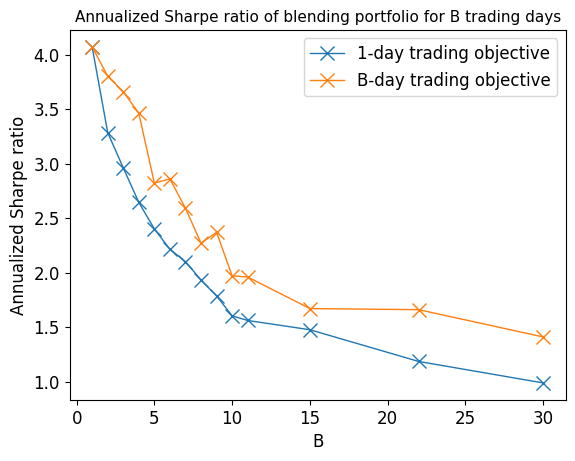

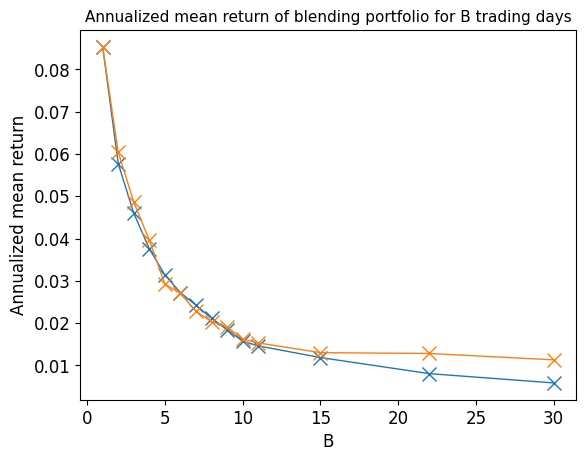

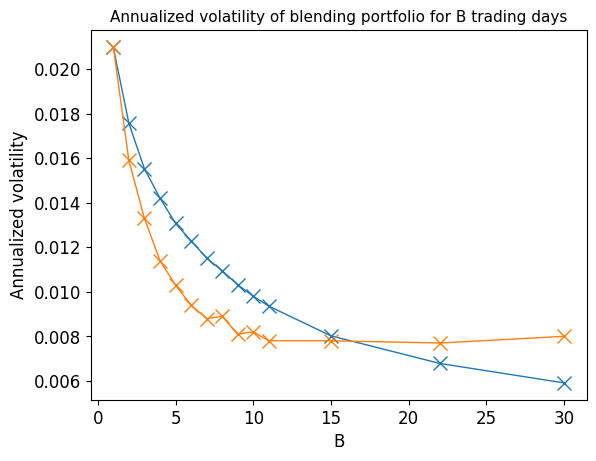

In [67]:
plot_arb_persistence_stats(arb_stats, opt_arb_stats, oosdates, days=DAYS)

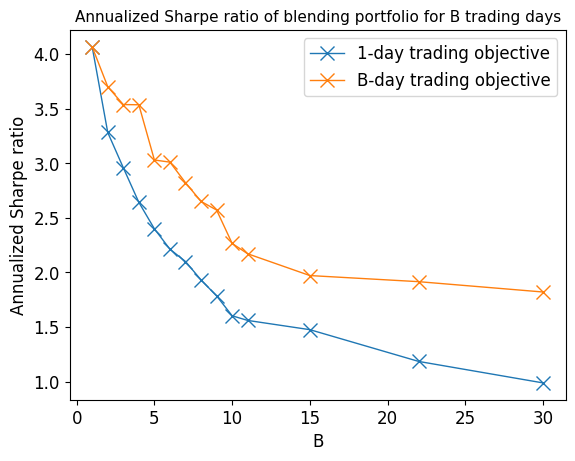

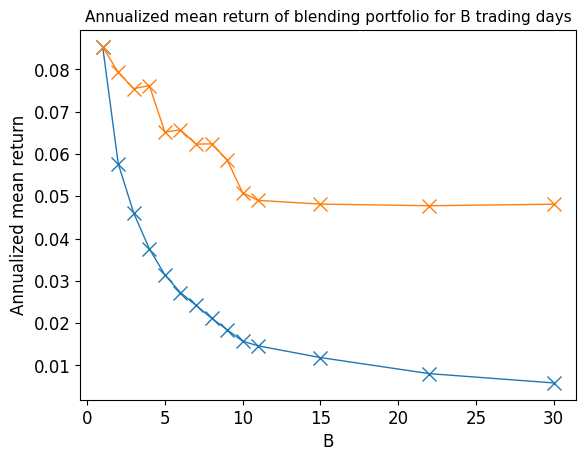

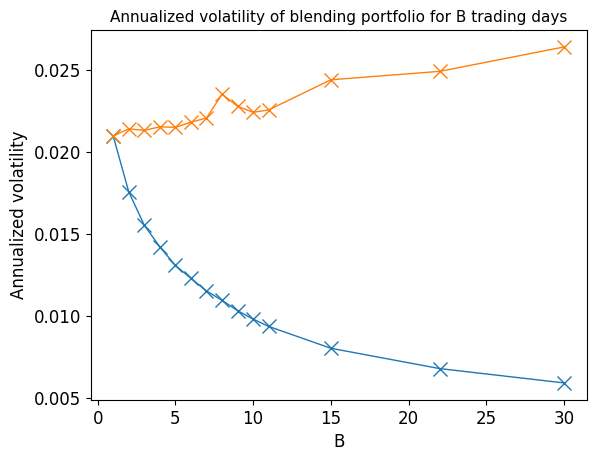

In [68]:
plot_arb_persistence(arb_rets, opt_arb_rets, oosdates, days=DAYS)

### B-day trading, non-overlapping

In [21]:
def trade_days(
    data,
    weights_complete,
    holding_days=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 15, 22, 30],
    frictions=False,
    progress=False,
    output_path=os.path.join(os.getcwd(), "results", "Unknown"),
):
    """
    Compute returns for a strategy that holds a portfolio of assets for `holding_days` days.

    `data` is a (T+k,N) array of asset returns
    `weights_complete` is a (T,N) array of asset weights (NOT residual weights)
    `holding_days` is an array of integers greater than 1
    """
    if os.path.exists(output_path):
        rets = np.load(output_path)['rets']
        return rets
    T,N = weights_complete.shape
    assert(data.shape[0] >= T)
    assert(data.shape[1] == N)
    data = data[-T:]
    rets = np.zeros((len(holding_days),T))
    if progress:
        print(f"{datetime.datetime.now()}: Computing returns for holding days: {holding_days}")
    for B in holding_days:
        for t in range(B,T):
            b_day_weights = np.repeat(weights_complete[t-B+1:t-B+2,:], B, axis=0)
            b_day_asset_returns = data[t-B+1:t+1]
            b_day_ret = np.sum(b_day_weights * b_day_asset_returns, axis=1)
            cost = 0
            if frictions:
                if t < B:
                    turnover = np.sum(np.abs(weights_complete[t,:])) 
                else:
                    turnover = np.sum(np.abs(weights_complete[t,:] - weights_complete[t-B,:])) 
                short = np.sum(np.abs(b_day_weights[b_day_weights < 0]))
                cost = 0.0005 * turnover + 0.0001 * short
            rets[holding_days.index(B),t] = (np.cumprod(1 + b_day_ret)[-1] - 1) / B - cost / B
            if t % (T // 20) == 0:
                if progress:
                    print(f"{datetime.datetime.now()}: B={B}: At {t} of {T}")
                else:
                    print(f"B={B}: At {t} of {T}")
    # np.savez(output_path, holding_days=holding_days, rets=rets)
    return rets

In [25]:
holding_days=[1,2,3,4,5,6,7,8,9,10,11,15,22,30]

In [26]:
bdr = trade_days(oosrets, w, holding_days=holding_days, progress=True,
                 output_path="saved-results/b-day-returns.npz")

In [58]:
rdf = utils.load_results('saved-results/CNNTransformer', results_tag='holding-days')
rdf = rdf[rdf.results_tag.str.contains('GridChild-holding-days-merry-flea') \
          | rdf.results_tag.str.contains('GridChild-holding-days-hip-mayfly') \
          | rdf.results_tag.str.contains('GridChild-holding-days-fond-rat')]
bdr_opt = np.zeros((len(rdf), r.shape[0]))
for (i,b) in enumerate(sorted(rdf.holding_days.unique().tolist())):
    idx = rdf[rdf.holding_days == b].index[0]
    bdr_opt[i,:] = rdf.loc[idx]['returns']

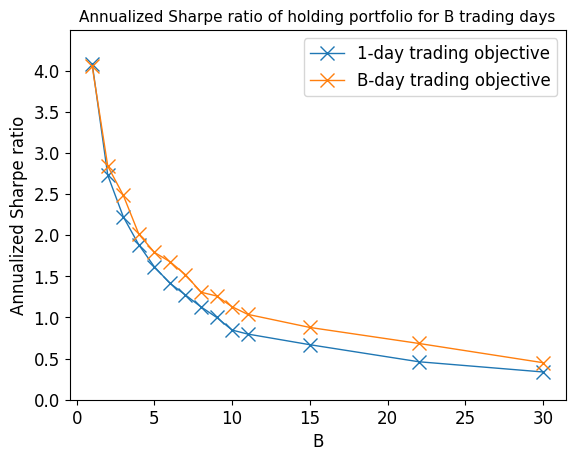

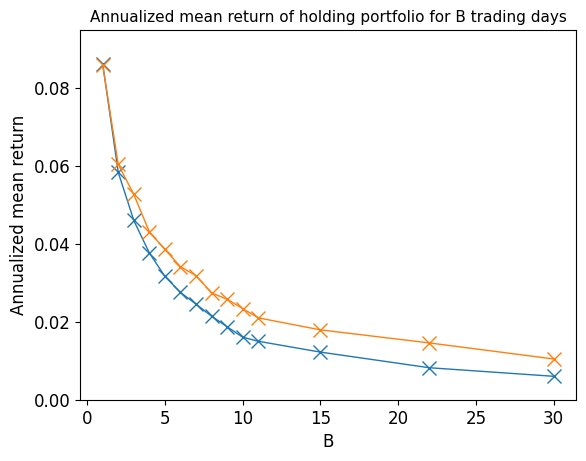

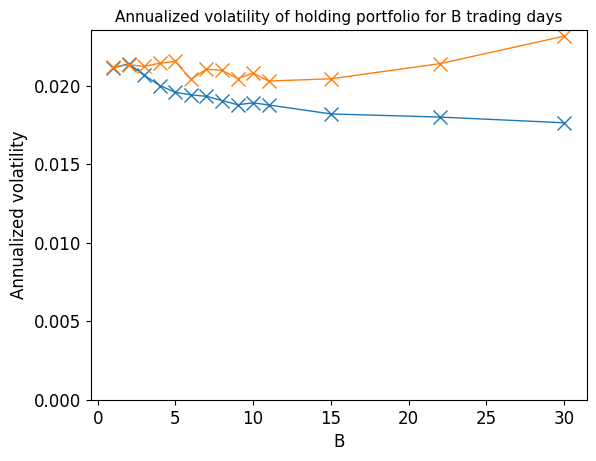

In [28]:
for (agg_name, agg_var, agg_func) in [('Annualized Sharpe ratio', 'sharpe', b_sharpe), 
                                      ('Annualized mean return', 'mean', b_ret), 
                                      ('Annualized volatility', 'std', b_std)]:
    plt.figure()
    data_agg = b_stat(bdr.T, holding_days, agg_func)
    data_agg_opt = b_stat(bdr_opt.T, holding_days, agg_func)
    plt.plot(holding_days, data_agg, marker="x", linewidth=1, label="1-day trading objective", markersize=10)
    plt.plot(holding_days, data_agg_opt, marker="x", linewidth=1, label="B-day trading objective", markersize=10)
    plt.title(f"{agg_name} of holding portfolio for B trading days")
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel("B", fontsize=12)
    plt.ylim(0, np.max(data_agg)*1.1)
    plt.ylabel(agg_name, fontsize=12)
    if 'Sharpe' in agg_name:
        plt.legend(loc="upper right", fontsize=12)
    # plt.savefig(f"plots/strategy-analysis/persistence_new_{agg_var}_avg.png", bbox_inches='tight')
    plt.show()

## Sparse portfolio policies

In [29]:
# percentile cutoff for residuals to make portfolios
percentiles = [0.2, 0.1, 0.05, 0.01]
# offset by 1000 to make comparable with model strategy returns, which don't trade first 4 years of data
offset = 1000 


def compute_top_policy_returns(
    weights: np.ndarray,
    oosdates: np.ndarray,
    oosrets: np.ndarray,
    residuals: np.ndarray,
    composition_matrix: np.ndarray,
    strategy_returns: np.ndarray,
    percentiles: list,
    top_type: str,
    lookback: int = 30,
    offset: int = 1000,
    frictions: bool = False,
    tag: str = None,
    plot: bool = False,
    progress: bool = False,
):
    filepath = f"saved-results/largest-{top_type}-policy-cumul-rets{'_'+tag if tag else ''}.npy"
    if os.path.exists(filepath):
        rets = np.load(filepath)
        if plot:
            plot_top_percent_policy_returns(oosdates, strategy_returns, percentiles, top_type, tag, rets)
        return rets
    a2c = np.count_nonzero(residuals, axis=0) >= lookback
    percentiles = sorted(percentiles, reverse=True)
    rets = np.zeros([weights.shape[0], len(percentiles)])
    T,N = weights.shape
    w_thresh = copy.deepcopy(weights)
    print(percentiles)
    mask = np.zeros(N, dtype=bool)
    old_w_t = np.zeros((len(percentiles), N))
    for t in range(T):
        for p in percentiles:
            mask[:] = False
            w_t = w_thresh[t,:].copy()
            n_t = np.sum(w_t != 0)
            # select top p% weights or resids
            k = int(p * n_t)
            if top_type == "weights":
                top_idxs = np.argpartition(np.abs(w_t), -k)[-k:]
                mask[top_idxs] = True
                w_t[~mask] = 0
                w_t /= np.sum(np.abs(w_t))
            elif top_type == "residuals":
                top_idxs = np.argpartition(np.abs(residuals[t+offset]), -k)[-k:]
                mask[top_idxs] = True
                resid_weights = composition_matrix[t+offset,:,:] @ w_t[super_mask]
                rw = np.zeros(N)
                rw[a2c] = resid_weights
                rw[~mask] = 0
                w_d = rw[a2c] @ composition_matrix[t+offset,:,:]
                w_t = np.zeros(N)
                w_t[super_mask] = w_d
                w_t /= np.sum(np.abs(w_t))
            else:
                raise Exception("Invalid top type")
            # calc return
            cost = 0
            if frictions:
                cost = 0.0005 * np.sum(np.abs(w_t - old_w_t[percentiles.index(p),:])) + 0.0001 * np.sum(np.abs(w_t[w_t < 0]))
            rets[t,percentiles.index(p)] = (oosrets[t,:] @ w_t) - cost
            old_w_t[percentiles.index(p),:] = w_t.copy()
            if progress and t % 50 == 0:
                if percentiles.index(p) == 0:
                    print(datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"), top_type, 'n_t', n_t, "at", t, "of", T)
                print("pct", p, 'k', k, f"return {rets[t, percentiles.index(p)]:0.6f}", "nnz", np.sum(w_t != 0))
                if percentiles.index(p) == len(percentiles) - 1:
                    print(f"orig return: weights {oosrets[t,:] @ w_thresh[t]:0.6f}, rets {r[t]:0.6f}")
                    print('----')
    np.save(filepath, rets)
    if plot:
        plot_top_percent_policy_returns(oosdates, strategy_returns, percentiles, top_type, tag, rets)
    return rets

def plot_top_percent_policy_returns(oosdates, strategy_returns, percentiles, top_type, tag, rets):
    plt.figure()
    for i in range(rets.shape[1]):
        plt.plot(oosdates, np.cumprod(1+rets[:,i], axis=0), label=f"p={percentiles[i]:.0%}")
    plt.plot(oosdates, np.cumprod(1+strategy_returns), label="p=100%")
    plt.legend()
    plt.title(f"Cumulative returns of keeping largest p% {top_type} {f'({tag})' if tag else ''}")
    # plt.savefig(f"plots/strategy-analysis/top-{top_type}-policy-cumul-rets{'_'+tag.replace(' ','_') if tag else ''}.png")

In [30]:
tw_rets = compute_top_policy_returns(w, oosdates, oosrets, resids, cm, r, percentiles, "weights")
tr_rets = compute_top_policy_returns(w, oosdates, oosrets, resids, cm, r, percentiles, "residuals")

In [31]:
print([1] + percentiles)

[1, 0.2, 0.1, 0.05, 0.01]


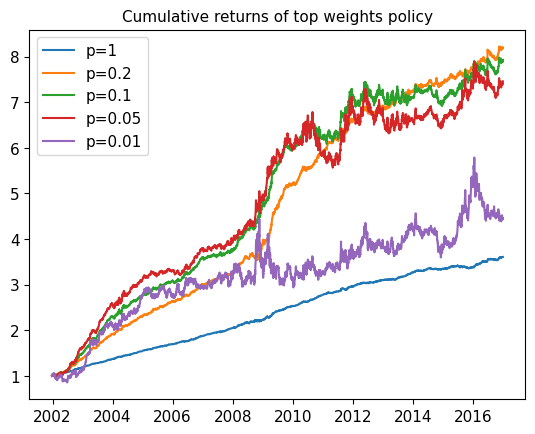

<Figure size 640x480 with 0 Axes>

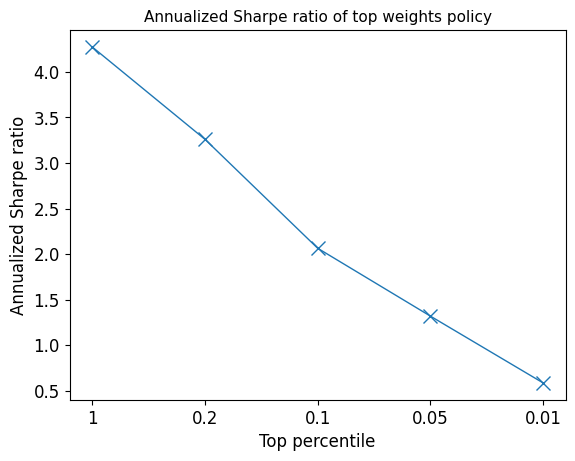

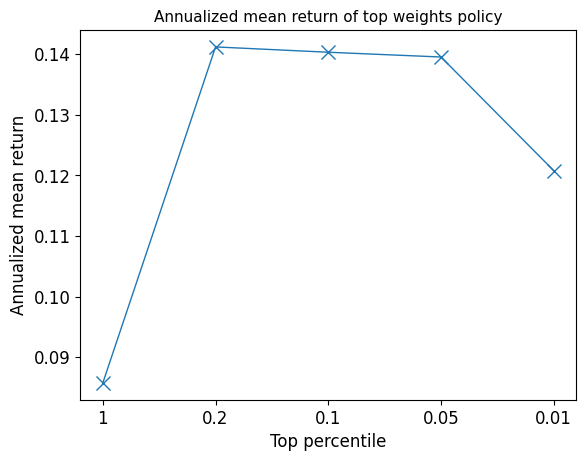

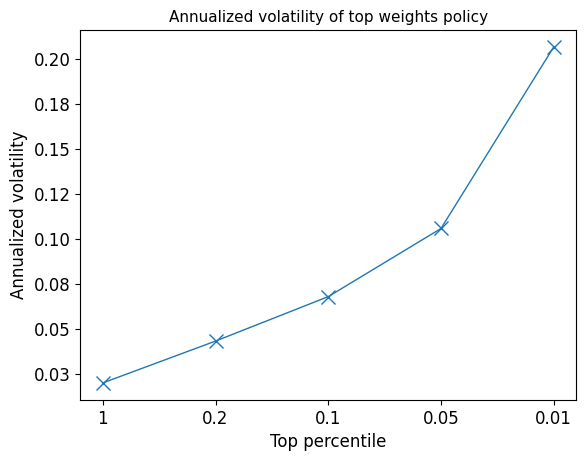

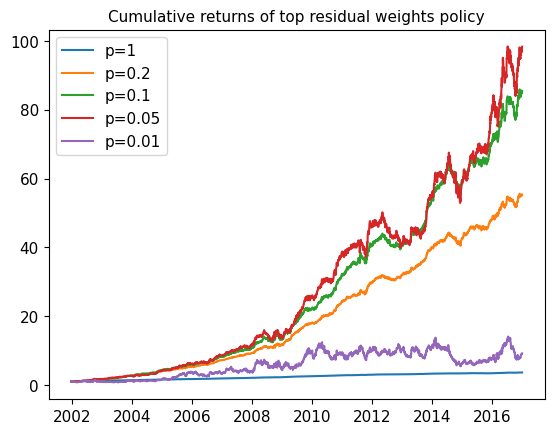

<Figure size 640x480 with 0 Axes>

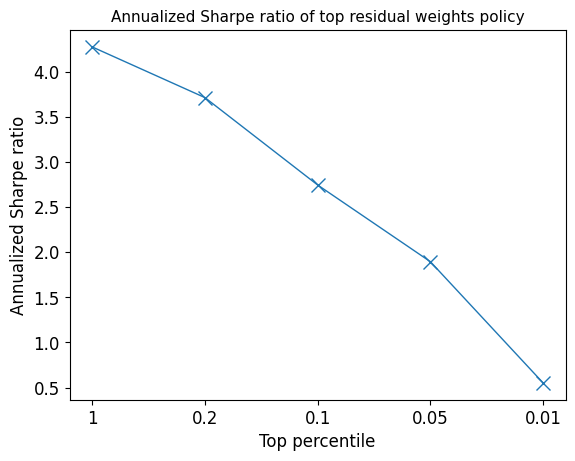

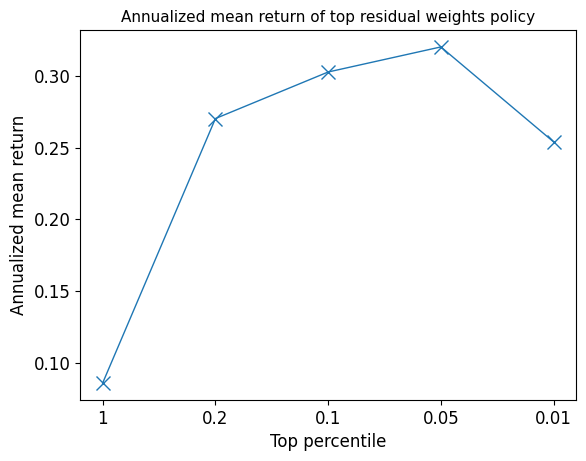

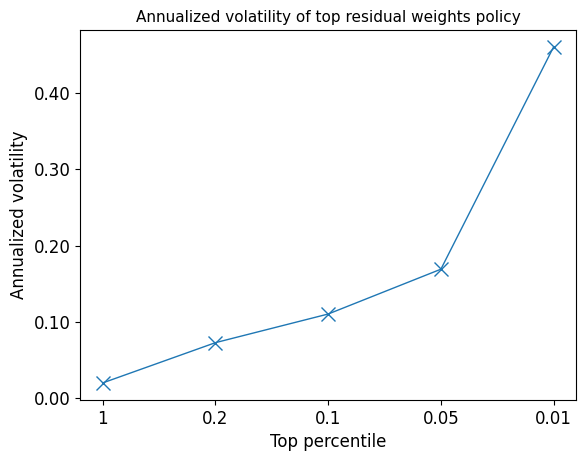

In [33]:
for (title_part, tag, top_rets) in [  # add top_rets_opt and each optimized array as last tuple item in each tuple entry in the below list of tuples
    ("top weights policy", "weights", tw_rets),
    ("top residual weights policy", "residuals", tr_rets),
]:
    plt.figure()
    plt.plot(oosdates, np.cumprod(1+r), label="p=1")
    for i in range(top_rets.shape[1]):
        plt.plot(oosdates, np.cumprod(1+top_rets[:,i], axis=0), label=f"p={percentiles[i]}")
    plt.legend()
    plt.title("Cumulative returns of " + title_part)
    # plt.savefig(f"plots/strategy-analysis/top_policy_cumul-rets_{tag}.png")
    plt.figure()
    for (agg_name, agg_var, agg_func) in [('Annualized Sharpe ratio', 'sharpe', ann_sharpe), 
                                          ('Annualized mean return', 'mean', ann_ret), 
                                          ('Annualized volatility', 'std', ann_std)]:
        #plt.figure()
        fig, ax = plt.subplots()
        plt.plot([str(p) for p in [1] + percentiles], np.hstack([agg_func(r), agg_func(top_rets)]), marker="x", linewidth=1, markersize=10) #, label="Not optimized")
        # plt.plot([str(p) for p in [1] + percentiles], np.hstack([agg_func(r), agg_func(top_rets_opt)]), marker="*", linewidth=0.25, label="Optimized")
        plt.title(f"{agg_name} of {title_part}")
        plt.xlabel("Top percentile", fontsize=12)
        # plt.xticks(ticks=[1] + percentiles, labels=[1] + percentiles)
        plt.ylabel(agg_name, fontsize=12)
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        if 'mean' in agg_name or 'volatility' in agg_name:
            from matplotlib.ticker import FormatStrFormatter
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        # plt.legend(loc="upper right")
        # plt.savefig(f"plots/strategy-analysis/top_policy_{agg_var}_{tag}.png")
        plt.show()

## Naive reversal strategies

In [34]:
def preprocess_cumsum(data, lookback):
    """
    Preprocess TxN numpy ndarray `data` into cumulative sum windows of integer length `lookback`.
    For use with residual returns time series, to create residual cumulative returns time series.
    """
    signal_length = lookback
    T,N = data.shape
    cumsums = np.cumsum(data, axis=0)
    windows = np.zeros((T-lookback, N, signal_length), dtype=np.float32)
    idxs_selected = np.zeros((T-lookback,N), dtype=bool)
    for t in range(lookback,T):
        # chooses stocks which have no missing returns in the t-th lookback window
        idxs_selected[t-lookback,:] = ~np.any(data[(t-lookback):t,:] == 0, axis = 0).ravel() 
        idxs = idxs_selected[t-lookback,:]
        
        if t == lookback:
            windows[t-lookback,idxs,:] = cumsums[t-lookback:t,idxs].T
        else:
            # Probably unnecessary given the conv normalization, but is just to have the same setting as in the OU case
            windows[t-lookback,idxs,:] = cumsums[t-lookback:t,idxs].T - cumsums[t-lookback-1,idxs].reshape(int(sum(idxs)),1)
    idxs_selected = torch.as_tensor(idxs_selected)
    return windows, idxs_selected

lookback = 30
windows, idxs_selected = preprocess_cumsum(resids, lookback)

In [35]:
if os.path.exists("saved-results/nm_rets.npy"):
    nm_rets = np.load("saved-results/nm_rets.npy")
else:
    # percentile cutoff for residuals to make long-short momentum portfolios
    percentile = 0.2
    # offset by 1000 to make comparable with model strategy returns, which don't trade first 4 years of data (they're used for training instead)
    offset = 1000
    # lags to construct momentum portfolios for
    lags = [1,2,3,4,5,6,7,8,9,10,11,15,22,30]
    # log progress?
    progress = False

    a2c = np.count_nonzero(resids, axis=0) >= 30
    nm_rets = np.zeros([r.shape[0], len(lags)])
    T,N = resids.shape
    abs_sums2 = np.zeros((T,len(lags)))

    if a2c.sum() < cm.shape[2]:
        cm_filtered = cm[:,a2c[fma2c],:]

    print("Computing returns")
    for t in range(offset + lookback, T-lookback):
        selected_resids = windows[t, idxs_selected[t-lookback,:], :]
        n_t = selected_resids.shape[0]
        k = int(percentile * n_t)
        for lag in lags:
            top_idxs = np.argpartition(selected_resids[:,-lag], -k)[-k:]
            btm_idxs = np.argpartition(selected_resids[:,-lag],  k)[:k]
            w_mom = np.zeros(n_t)
            w_mom[top_idxs] = 1
            w_mom[btm_idxs] = -1
            w_mom /= 2*k
            # change to asset space and normalize L1 norm of weights vector
            wf_mom = np.zeros(N)
            wf_mom[idxs_selected[t-lookback,:]] = w_mom
            if a2c.sum() < cm.shape[2]:
                w2_mom = wf_mom[a2c] @ cm_filtered[t-lookback,:,:]
            else:
                w2_mom = wf_mom[a2c] @ cm[t-lookback,:,:]
            abs_sum2 = np.sum(np.abs(w2_mom))
            abs_sum = np.sum(np.abs(w_mom))
            w2_mom /= abs_sum2
            wf_mom /= abs_sum2
            w_mom  /= abs_sum2
            # calc return
            nm_rets[t-lookback - offset,lags.index(lag)] = resids[t-lookback, idxs_selected[t-lookback,:]] @ w_mom
            # logging
            abs_sums2[t-lookback-offset,lags.index(lag)] = abs_sum2
            if progress and (t % 50 == 0 or t >= T-1) and (lag in [1,5,22,30]):
                print(datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
                print("at", t, "of", T, "lag", lag)
                print("selected_resids.shape", selected_resids.shape, "mom return", nm_rets[t-lookback - offset,lags.index(lag)], \
                    "abssum2", abs_sum2, "nnz", np.sum(w_mom != 0))
        if progress and (t % 50 == 0 or t >= T-1) and (lag in [1,5,22,30]): 
            print('---')
    # np.save('saved-results/nm_rets.npy', nm_rets)

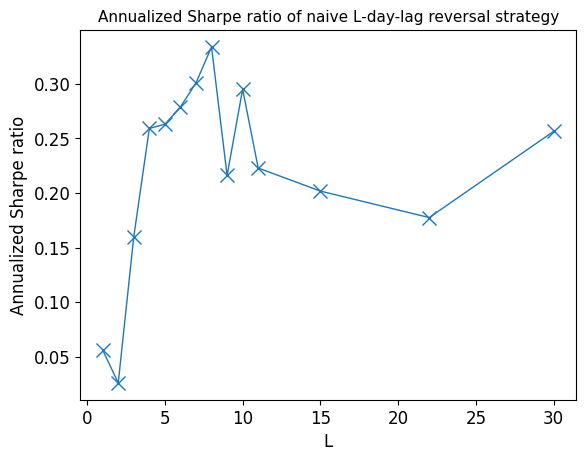

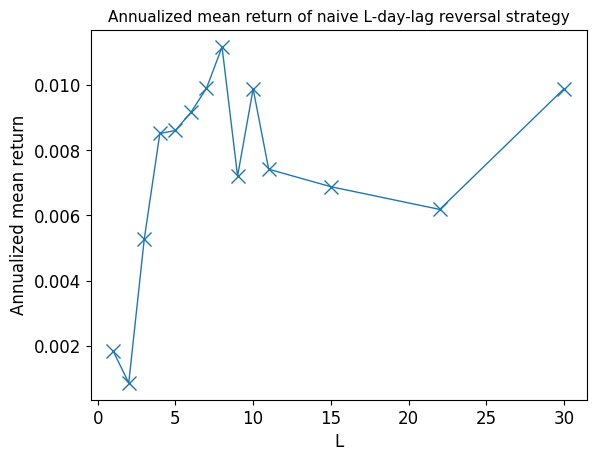

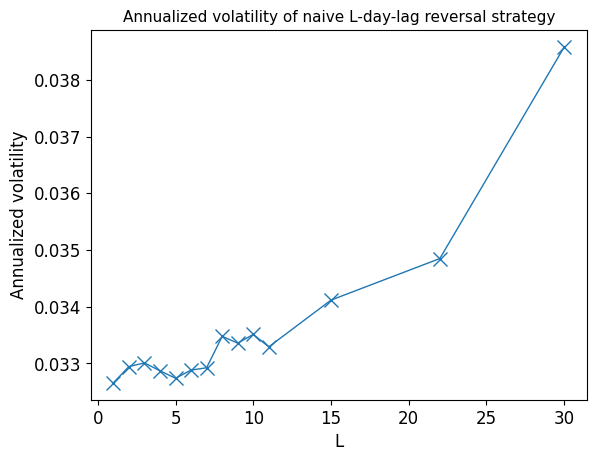

In [36]:
holding_days = [1,2,3,4,5,6,7,8,9,10,11,15,22,30]
for (agg_name, agg_var, agg_func) in [('Annualized Sharpe ratio', 'sharpe', ann_sharpe), 
                                      ('Annualized mean return', 'mean', ann_ret), 
                                      ('Annualized volatility', 'std', ann_std)]:
    plt.figure()
    if 'mean' in agg_name or 'Sharpe' in agg_name:
        reversal_agg_stat = -1 * agg_func(nm_rets)
    else:
        reversal_agg_stat = agg_func(nm_rets)
    plt.plot(holding_days, reversal_agg_stat, marker="x", linewidth=1, markersize=10) #, label="Not optimized")
    # plt.plot(holding_days, agg_func(nm_rets_opt), marker="*", linewidth=0.25, label="Optimized")
    plt.title(f"{agg_name} of naive L-day-lag reversal strategy")
    plt.xlabel("L", fontsize=12)
    plt.ylabel(agg_name, fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    # plt.legend(loc="upper right")
    # plt.savefig(f"plots/strategy-analysis/naive_momentum_{agg_var}.png")
    plt.show()

## Arbitrage vs risk premium and factor-mimicking portfolios

### Factor and residual component

In [ ]:
# get month's returns
monthrets = np.load('saved-results/residuals/ipca/rmonth/rmonth_647_month_5_factors_420_initialMonths_240_window_12_reestimationFreq_0.01_cap.npy')
# get month's IPCA betas
betas = np.load('saved-results/residuals/ipca/betas/beta_647_month_5_factors_420_initialMonths_240_window_12_reestimationFreq_0.01_cap.npy').T
# get month's factors
mfactors = np.load('saved-results/residuals/ipca/factors/factors_647_month_5_factors_420_initialMonths_240_window_12_reestimationFreq_0.01_cap.npy').T

In [48]:
factor_mimicking_portfolios = mfactors @ betas

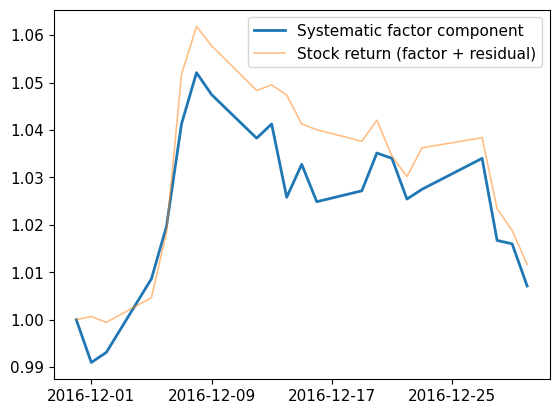

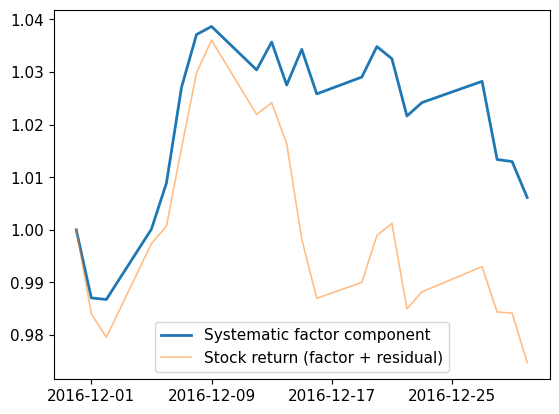

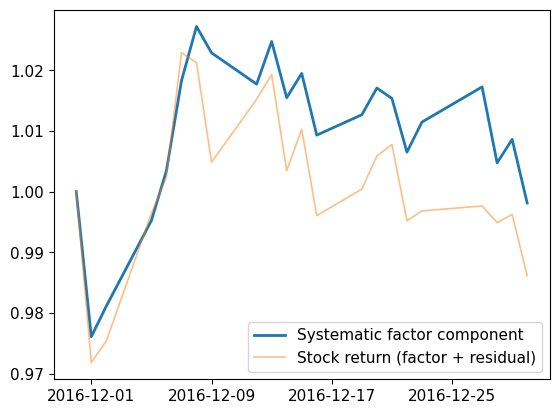

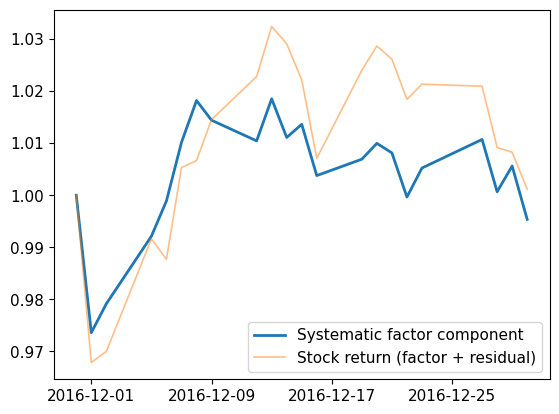

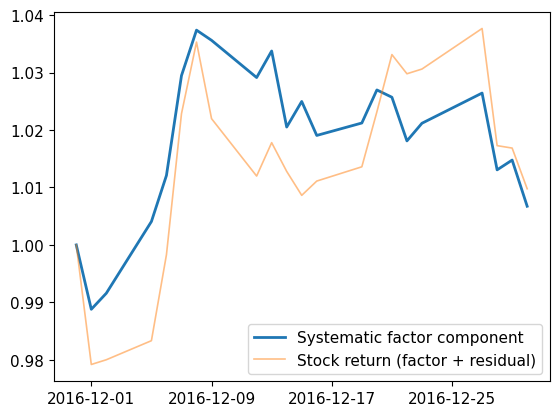

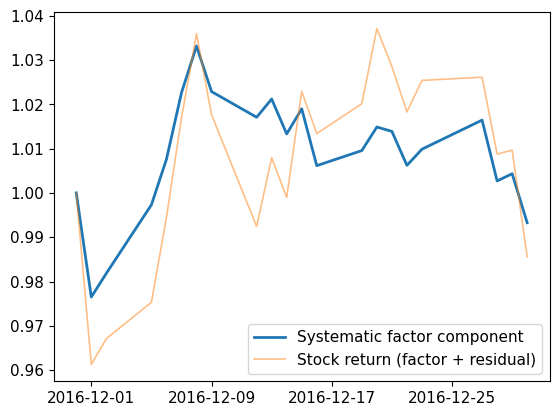

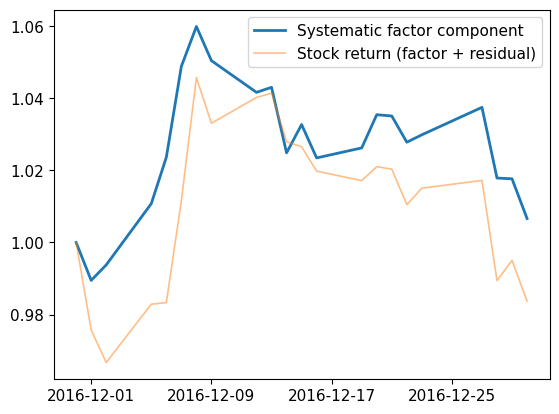

In [49]:
times = [dd.date() for dd in oosdates[-22:]]

for i in [41, 608, 445, 341, 110, 253, 459]:    # some indices for month 647 IPCA5
    fig,ax = plt.subplots()
    fmp = np.cumprod(1 + np.concatenate([np.zeros(1), factor_mimicking_portfolios[:,i]]))
    plt.plot(times, fmp, label='Systematic factor component', linewidth=2)
    stock = np.cumprod(1 + np.concatenate([np.zeros(1), monthrets[:,i]]))
    plt.plot(times, stock, label='Stock return (factor + residual)', alpha=0.5, linewidth=1.2)
    plt.legend()
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    # if not os.path.exists('plots/factor-mimicking-portfolios'):
    #     os.makedirs('plots/factor-mimicking-portfolios')
    # plt.savefig(f'plots/factor-mimicking-portfolios/ipca5_month{647}_id{i}.png')

### Returns of statarb vs factor portfolio

In [51]:
factors = np.load("saved-results/residuals/ipca/factors/IPCA_factors_5_factors_420_initialMonths_240_window_12_reestimationFreq_0.01_cap.npy")
factors.shape

(4781, 5)

In [52]:
facs = factors[-3781:,:]
rr = r[-3781:]
strats = np.concatenate([facs, rr[:,np.newaxis]], axis=1)
dlsa_rets = strats[:,-1]

In [53]:
ipca_factors = factors[-3781:,:]
dlsa_rets = strats[:,-1]
mod = sm.OLS(dlsa_rets, ipca_factors)
result = mod.fit()

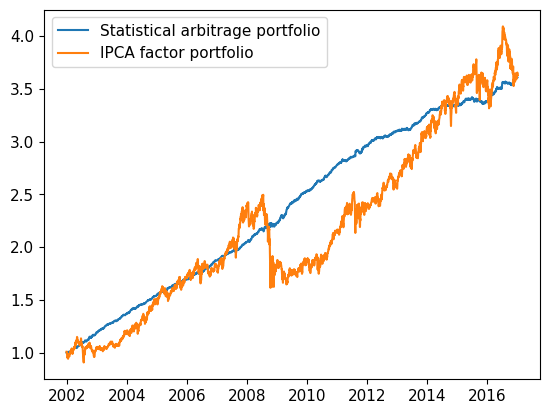

In [ ]:
plt.plot(oosdates[-3781:], np.cumprod(1+dlsa_rets), label='Statistical arbitrage portfolio')
plt.plot(oosdates[-3781:], np.cumprod(1+1.65*(ipca_factors @ result.params/np.abs(result.params).sum())), label='IPCA factor portfolio')
plt.legend()
# plt.savefig("plots/factor-mimicking-portfolios/ipca-factor-vs-statarb-portfolios.png")

### Portfolio optimization

#### Mean-var just on IPCA

In [55]:
lookback_days = 1000  # match training length

rets = []
print('lookback:', lookback_days)
for t in range(lookback_days, factors.shape[0]):
    ft = factors[t-lookback_days:t,:]
    mean = np.mean(ft, axis=0)
    cov = np.cov(ft.T)
    pw = np.linalg.pinv(cov) @ mean
    pw /= np.ones(5) @ np.linalg.pinv(cov) @ mean
    pw /= np.abs(pw).sum()
    rets.append(pw @ factors[t,:])
rets = np.array(rets)
print(round(ann_sharpe(rets),2), round(ann_ret(rets),3), round(ann_std(rets),3))

lookback: 1000
0.84 0.095 0.113


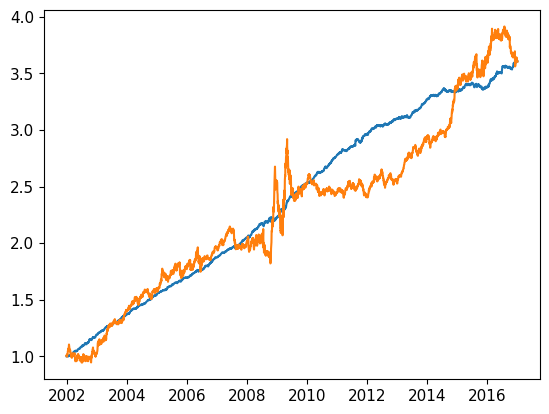

In [57]:
plt.plot(oosdates[-rets.shape[0]:], np.cumprod(1+dlsa_rets[-rets.shape[0]:]))
plt.plot(oosdates[-rets.shape[0]:], np.cumprod(1+0.96*rets))